In [24]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'customer_id': [1, 2, 3],
        'purchase1': [100, 200, 150],
        'purchase2': [80, 120, 130]}
df = pd.DataFrame(data)

df['total_purchase'] = df['purchase1'] + df['purchase2']
df

,customer_id,purchase1,purchase2,total_purchase
0,1,100,80,180
1,2,200,120,320
2,3,150,130,280


In [25]:
# 예시 데이터프레임 생성
data = {'region': ['A', 'A', 'B', 'B', 'C'],
        'income': [5000, 6000, 5500, 6200, 5800]}
df = pd.DataFrame(data)

# 지역별 평균 소득 계산
avg_income = df.groupby('region')['income'].mean().reset_index()
avg_income.rename(columns={'income': 'avg_income'}, inplace=True)
avg_income

,region,avg_income
0,A,5500.0
1,B,5850.0
2,C,5800.0


In [26]:
avg_income = df.groupby('region')['income'].transform('mean')
avg_income

0    5500.0
1    5500.0
2    5850.0
3    5850.0
4    5800.0
Name: income, dtype: float64

In [27]:
df['region_avg_income'] = avg_income
df

,region,income,region_avg_income
0,A,5000,5500.0
1,A,6000,5500.0
2,B,5500,5850.0
3,B,6200,5850.0
4,C,5800,5800.0


In [28]:
# 예시 데이터프레임 생성
data = {'person': ['X', 'Y', 'Z'],
        'income': [4000, 5000, 6000]}
df = pd.DataFrame(data)

# 전체 평균 소득 계산
mean_income = df['income'].mean()

# 평균 대비 소득 차이 계산
df['income_diff'] = df['income'] - mean_income
df

,person,income,income_diff
0,X,4000,-1000.0
1,Y,5000,0.0
2,Z,6000,1000.0


In [29]:
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, 5000, 6000, 4500]}
df = pd.DataFrame(data)

# 기준점 설정 (전체 평균 소득)
mean_income = df['avg_income'].mean()

# 소득 수준 분류
def categorize_income(x):
    if x > mean_income:
        return '높음'
    elif x == mean_income:
        return '보통'
    else:
        return '낮음'

df['income_level'] = df['avg_income'].apply(categorize_income)
df

,region,avg_income,income_level
0,A,5500,높음
1,B,5000,낮음
2,C,6000,높음
3,D,4500,낮음


In [30]:
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)

print(df.info())
print(df.isna().sum())
print(df.isna().mean())

# 평균 나이 계산
mean_age = df['age'].mean()

# 결측값 대체
df.fillna({'age': mean_age}, inplace=True)
df

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    4 non-null      str    
 1   age     2 non-null      float64
dtypes: float64(1), str(1)
memory usage: 196.0 bytes
None
name    0
age     2
dtype: int64
name    0.0
age     0.5
dtype: float64


,name,age
0,Alice,25.0
1,Bob,27.5
2,Charlie,30.0
3,David,27.5


In [31]:
df.isna().sum()

name    0
age     0
dtype: int64

In [45]:
data = {'student': ['A', 'B', 'C', 'D', 'E'],
        'score': [80, np.nan, 90, np.nan, 85]}
df = pd.DataFrame(data)

np.random.seed(0)
nan_indices = df[df['score'].isnull()].index
nan_indices

RangeIndex(start=1, stop=5, step=2)

In [46]:
df.loc[nan_indices, 'score'] = np.random.choice(df['score'].dropna(), size=len(nan_indices))
df

,student,score
0,A,80.0
1,B,80.0
2,C,90.0
3,D,90.0
4,E,85.0


In [51]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 예시 데이터프레임 생성
data = {'feature1': [1.0, 2.1, np.nan, 4.3, 5.2],
        'feature2': [3.2, np.nan, 1.8, 2.5, 4.0]}
df = pd.DataFrame(data)

# 다중대치법 적용
imputer = IterativeImputer(max_iter=10, random_state=0)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df_imputed

,feature1,feature2
0,1.000000,3.200000
1,2.100000,2.874009
2,3.148439,1.800000
3,4.300000,2.500000
4,5.200000,4.000000


In [52]:
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

# 사분위수 계산
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

# 이상값 기준 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상값 식별
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
outliers

,value
5,100


In [65]:
import pandas as pd
from scipy.stats import iqr

data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

IQR = iqr(df['value'])
IQR

np.float64(5.0)

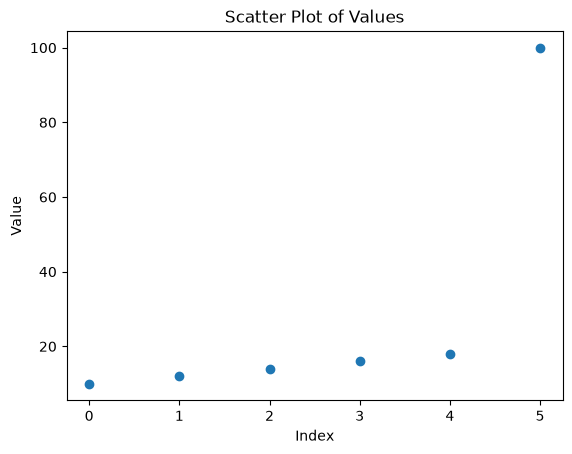

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

# 산점도 그리기
plt.scatter(df.index, df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [ ]:
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 평균과 표준편차 계산
mean = df['score'].mean()
std = df['score'].std()

# Z-변환 적용
df['z_score'] = (df['score'] - mean) / std
df

,score,z_score
0,70,-1.264911
1,80,-0.632456
2,90,0.000000
3,100,0.632456
4,110,1.264911


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['z_score'] = scaler.fit_transform(df[['score']])
df

,score,z_score
0,70,-1.414214
1,80,-0.707107
2,90,0.000000
3,100,0.707107
4,110,1.414214


In [55]:
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 최소값과 최대값 계산
min_val = df['score'].min()
max_val = df['score'].max()

# [0-1] 변환 적용
df['normalized_score'] = (df['score'] - min_val) / (max_val - min_val)
df

,score,normalized_score
0,70,0.00
1,80,0.25
2,90,0.50
3,100,0.75
4,110,1.00


In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['normalized_score'] = scaler.fit_transform(df[['score']])
df

,score,z_score,normalized,normalized_score
0,70,-1.414214,0.00,0.00
1,80,-0.707107,0.25,0.25
2,90,0.000000,0.50,0.50
3,100,0.707107,0.75,0.75
4,110,1.414214,1.00,1.00


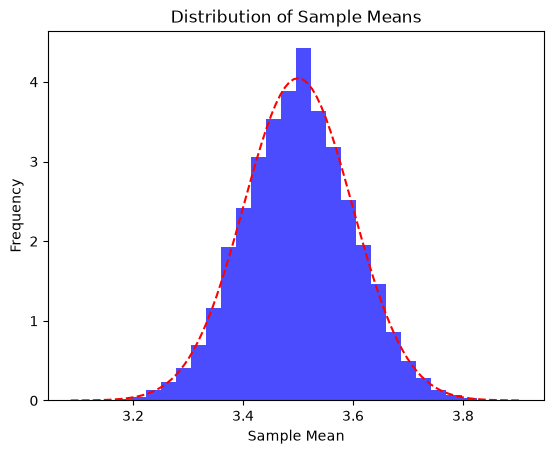

In [70]:
# 표본 크기와 시도 횟수 설정
n = 300  # 표본 크기
trials = 100000  # 시도 횟수

# 표본평균 저장 리스트
sample_means = []

for _ in range(trials):
    samples = np.random.randint(1, 7, n)  # 주사위 눈 1~6 사이의 정수
    sample_means.append(np.mean(samples))

# 히스토그램 그리기
plt.hist(sample_means, bins=30, density=True, alpha=0.7, color='blue')

# 정규분포 곡선 그리기
from scipy.stats import norm
mu = 3.5  # 주사위 눈의 평균
sigma = np.sqrt(35/12) / np.sqrt(n)  # 주사위 눈의 분산과 표본 크기를 이용한 표준편차
x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()